<a href="https://colab.research.google.com/github/aryac-2006/Optional-Task---S-18/blob/main/Insurance_Dataset_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [ ]:
filepath = "./insurance.csv"

In [ ]:
# Load the insurance dataset
df = pd.read_csv(filepath)

# Display the first 5 rows
print("First 5 rows of the insurance dataset:\n")
df.head(5)

First 5 rows of the insurance dataset:



,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [ ]:
# Display the Last 5 rows
print("Last 5 rows of the insurance dataset:\n")
df.tail(5)

Last 5 rows of the insurance dataset:



,age,sex,bmi,children,smoker,region,expenses
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95
1337,61,female,29.1,0,yes,northwest,29141.36


In [ ]:
# Shape of the data
print("1) Shape of the data (rows, columns):\n")
print(df.shape)

# Column names and data types (info())
print("\n2) Column names and data types:\n")
df.info()

# Statistical summary of numerical columns (describe())
print("\n3) Statistical summary of numerical columns:\n")
df.describe()

1) Shape of the data (rows, columns):

(1338, 7)

2) Column names and data types:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

3) Statistical summary of numerical columns:



,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [ ]:
# df.isnull().sum() :-
# Displays the number of missing values in each column

print("Null value in each column:\n")
df.isnull().sum()


Null value in each column:



,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0


In [ ]:
# ======= numerical columns in the datase ========

print("Numerical Columns:")
print(df.select_dtypes(include="number").columns)

# select_dtypes() selects columns based on their data type.
# include = 'number' selects all numerical columns (such as int and float).
# .columns displays only the names of those columns.

# ======== categorical columns in the datase =======

print("\nCategorical Columns:")
print(df.select_dtypes(include="object").columns)

# include='object' selects all text (string) columns.


Numerical Columns:
Index(['age', 'bmi', 'children', 'expenses'], dtype='object')

Categorical Columns:
Index(['sex', 'smoker', 'region'], dtype='object')


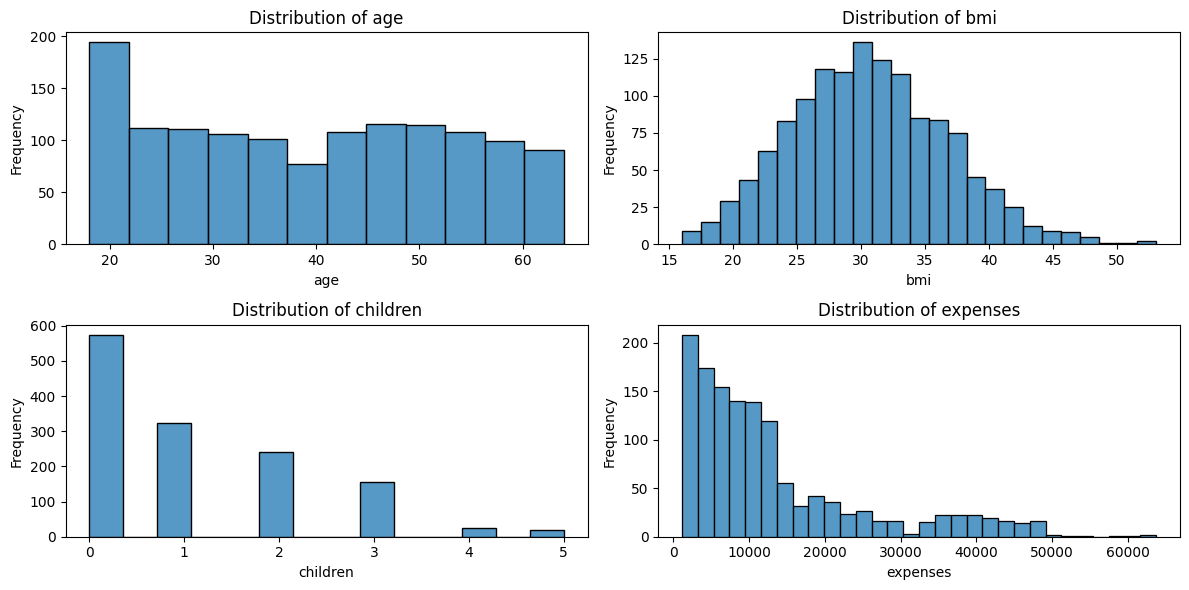

In [ ]:
# List of numerical columns
columns = ["age", "bmi", "children", "expenses"]

plt.figure(figsize=(12, 6))
# Create one histogram for each column
for i, col in enumerate(columns, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col])
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

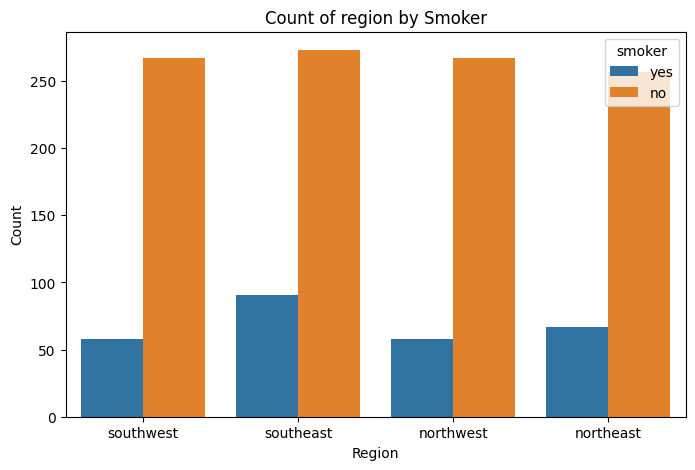

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x = "region", hue = "smoker", data = df)
plt.title(f"Count of region by Smoker")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

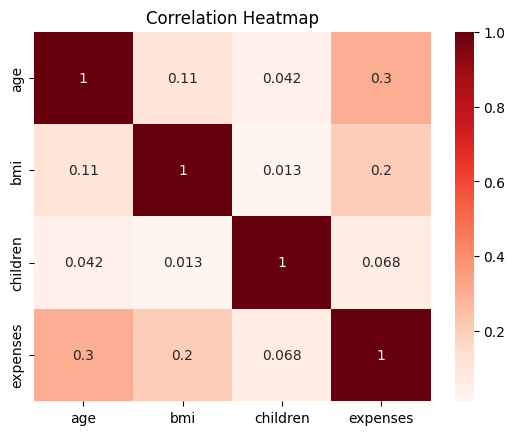

In [ ]:
# Calculate correlation of numerical columns
corr = df.corr(numeric_only = True)

# Create heatmap
sns.heatmap(corr, annot=True, cmap="Reds")

# Add title
plt.title("Correlation Heatmap")

# Display heatmap
plt.show()

In [ ]:
# Find the average insurance charges
print("1) Average Expenses:")
print(df["expenses"].mean())

# Find the maximum insurance expenses
print("\n2) Maxmimum Expenses:")
print(df["expenses"].max())

# Find the minimum insurance expenses
print("\n3) Minimum Expenses:")
print(df["expenses"].min())

# Compare average charges of smokers and non-smokers
print("\n4) Average Expenses for Smokers:\n")
print(df.groupby("smoker")["expenses"].mean())


1) Average Expenses:
13270.422414050823

2) Maxmimum Expenses:
63770.43

3) Minimum Expenses:
1121.87

4) Average Expenses for Smokers:

smoker
no      8434.268449
yes    32050.231971
Name: expenses, dtype: float64


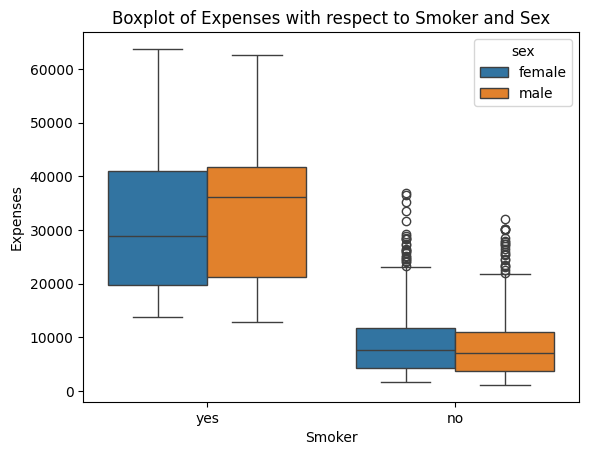

In [ ]:
# Create a boxplot of expenses with respect to smoker and sex.
sns.boxplot(x = df["smoker"], y = df["expenses"], hue = df["sex"])
plt.title("Boxplot of Expenses with respect to Smoker and Sex")
plt.xlabel("Smoker")
plt.ylabel("Expenses")
plt.show()

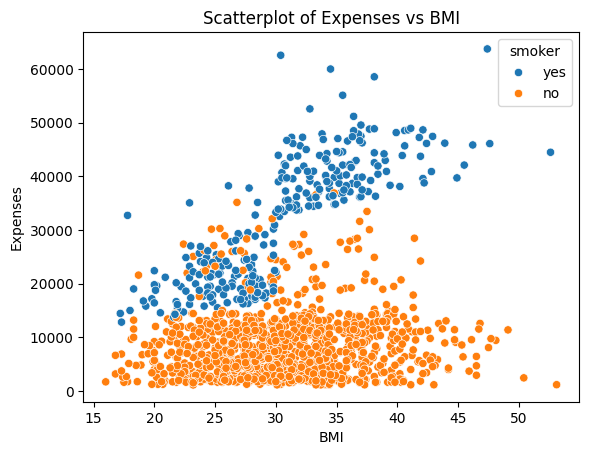

In [ ]:
# Scatterplot
sns.scatterplot(x = df["bmi"], y = df["expenses"], hue = df["smoker"])
plt.title("Scatterplot of Expenses vs BMI")
plt.xlabel("BMI")
plt.ylabel("Expenses")
plt.show()

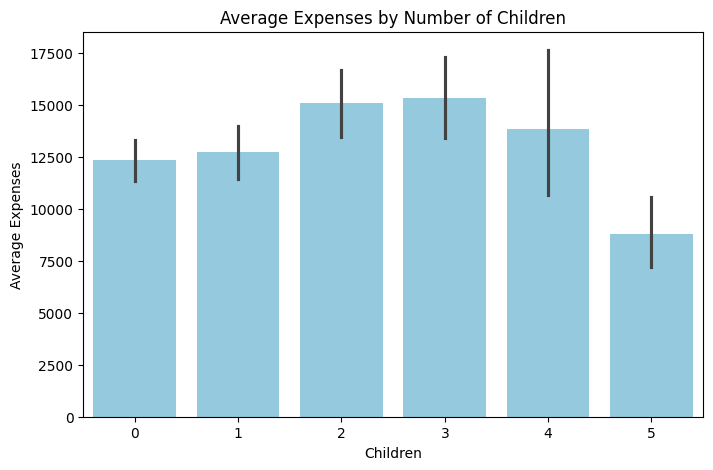

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x="children", y="expenses", data=df,color ="skyblue")

plt.title("Average Expenses by Number of Children")
plt.xlabel("Children")
plt.ylabel("Average Expenses")
plt.show()

In [ ]:
# Input Features
X = df.drop("expenses", axis=1)

print("-------------< Independent Features >-------------\n")
print(X.columns)

# Output/Target Feature
y = df["expenses"]

print("\n-------------< Dependent Feature >-------------\n")
print(y.name)

# Independent Features:
# age, sex, bmi, children, smoker, region

# Dependent Feature:
# expenses

-------------< Independent Features >-------------

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region'], dtype='object')

-------------< Dependent Feature >-------------

expenses


In [ ]:
# Encoding Categorical Variables

import pandas as pd

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=["sex", "smoker", "region"], drop_first=True)

print("Encoded Dataset:\n")
print(df_encoded.head())

Encoded Dataset:

   age   bmi  children  expenses  sex_male  smoker_yes  region_northwest  \
0   19  27.9         0  16884.92     False        True             False   
1   18  33.8         1   1725.55      True       False             False   
2   28  33.0         3   4449.46      True       False             False   
3   33  22.7         0  21984.47      True       False              True   
4   32  28.9         0   3866.86      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Select numeric independent features
X = df[["age", "bmi", "children"]]

# Apply Standard Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

# Convert scaled data into DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=X.columns)

# Show the first 5 rows of scaled data
print("-----------< First 5 rows of Scaled Data >-----------\n")
print(scaled_df.head())

-----------< First 5 rows of Scaled Data >-----------

        age       bmi  children
0 -1.438764 -0.453646 -0.908614
1 -1.509965  0.514186 -0.078767
2 -0.797954  0.382954  1.580926
3 -0.441948 -1.306650 -0.908614
4 -0.513149 -0.289606 -0.908614
